# 5-0b. 전국 수요 표현·정규화 진단 — PatchTST 전환 사전 EDA

> 5단계 구조 변경: LGBM → **Cross-Attention PatchTST + RevIN** (제주 3단계·6단계 solar 구조).
> 트리(LGBM)는 raw MW를 그냥 써도 됐지만 **NN은 큰 절대값·레벨 표류에 취약** → 표현을 먼저 정한다.
>
> **결정거리 (이 노트북이 답한다):**
> 1. 타깃 표현 = **raw MW** vs **RevIN**(윈도우별 표준화) vs **rec168 비율**(원점 앵커 대비)
> 2. context length(seq_len) = 168 / **336** / 504 / 720 중 어디 — 자기상관 지속성으로 좁힌다
> 3. (보조) 낮(09-15h) 과대 비대칭 손실 α 강도 — 낮↔밤 변동 구조
>
> 타깃 `real_demand_land`(MW). 학습창 train≤2024 / val 2025 / test 2026.
> **lag/rec 명시 피처는 PatchTST에선 제거**(past_y 윈도우가 자기상관을 직접 봄) — 그래서 context
> length가 곧 "모델이 보는 과거 길이" 결정이다.

In [1]:
import os, sqlite3, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

HERE = os.getcwd()
FIG = os.path.join(HERE, 'fig'); os.makedirs(FIG, exist_ok=True)
TAB = os.path.join(HERE, 'tab'); os.makedirs(TAB, exist_ok=True)
DB = os.path.normpath(os.path.join(HERE, '..', '..',
        '1. data_fetcher_and_db', 'data', 'input_data_land.db'))

# v2 지점선택(exp_features 정본과 동일)
STATIONS = ['daegwallyeong', 'wonju', 'seosan', 'pohang', 'yeonggwang']
SOLAR_SEL = ['seosan', 'yeonggwang']
WIND_SEL  = ['daegwallyeong', 'pohang']
pull = ['timestamp', 'real_demand_land', 'day_type']
pull += [f'temp_c_{s}' for s in STATIONS]
pull += [f'solar_rad_{s}' for s in SOLAR_SEL]
pull += [f'wind_spd_{s}' for s in WIND_SEL]

con = sqlite3.connect(DB)
raw = pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp'])
con.close()
raw = raw.sort_values('timestamp')
idx = pd.date_range(raw.timestamp.min(), raw.timestamp.max(), freq='h')
d = raw.set_index('timestamp').reindex(idx); d.index.name = 'timestamp'
d.loc[d.real_demand_land == 0, 'real_demand_land'] = np.nan
d['y'] = d['real_demand_land'].interpolate('time')
d['temp_c']   = d[[f'temp_c_{s}' for s in STATIONS]].apply(pd.to_numeric, errors='coerce').mean(1).interpolate('time')
d['solar_rad']= d[[f'solar_rad_{s}' for s in SOLAR_SEL]].apply(pd.to_numeric, errors='coerce').mean(1).interpolate('time')
d['wind_spd'] = d[[f'wind_spd_{s}' for s in WIND_SEL]].apply(pd.to_numeric, errors='coerce').mean(1).interpolate('time')
d['year'] = d.index.year; d['month'] = d.index.month; d['hour'] = d.index.hour; d['dow'] = d.index.dayofweek
print('rows', len(d), '| range', d.index.min(), '->', d.index.max())
print('y MW range %.0f ~ %.0f | NaN %d' % (d.y.min(), d.y.max(), d.y.isna().sum()))

rows 56616 | range 2020-01-01 00:00:00 -> 2026-06-16 23:00:00
y MW range 33372 ~ 96832 | NaN 0


## 1. 타깃 표현 3종 만들기

- **raw**: y (MW 그대로)
- **RevIN(diag)**: 윈도우별 표준화의 대리 진단 — 직전 336h 평균·표준편차로 z화
  `z = (y − roll_mean_336) / roll_std_336`. RevIN이 인스턴스마다 하는 일을 근사.
- **rec168 비율**: 원점 앵커(직전 168h 평균) 대비 비율 `r = y / roll_mean_168`.
  서빙에서 rec168은 원점에 알려진 스칼라라 전 지평(D+1..15) 안전.

표현이 좋다 = ① 연도별 분포가 안정(레벨 표류 흡수) ② train(≤2024)↔test(2026) 겹침이 큼
③ 스케일이 NN 친화적(±작음).

In [2]:
# trailing 윈도우(원점 가용성 모사: 현재 시각 포함 trailing). 진단용 분포 비교 목적.
roll_m336 = d.y.rolling(336, min_periods=336).mean()
roll_s336 = d.y.rolling(336, min_periods=336).std()
roll_m168 = d.y.rolling(168, min_periods=168).mean()

d['rep_raw']   = d.y
d['rep_revin'] = (d.y - roll_m336) / roll_s336
d['rep_ratio'] = d.y / roll_m168
REPS = {'raw (MW)': 'rep_raw', 'RevIN z(diag)': 'rep_revin', 'rec168 비율': 'rep_ratio'}

def overlap_coef(a, b, bins=80):
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    lo, hi = np.nanpercentile(np.concatenate([a, b]), [0.5, 99.5])
    edges = np.linspace(lo, hi, bins+1)
    ha, _ = np.histogram(a, edges, density=True); hb, _ = np.histogram(b, edges, density=True)
    w = edges[1]-edges[0]
    return float(np.minimum(ha, hb).sum()*w)  # OVL: 1=완전겹침, 0=분리

rows = []
tr_mask = d.year <= 2024; te_mask = d.year == 2026
for name, col in REPS.items():
    s = d[col]
    ovl = overlap_coef(s[tr_mask].values, s[te_mask].values)
    yr_mean = s.groupby(d.year).mean()
    drift = float(yr_mean.loc[2020:2024].max() - yr_mean.loc[2020:2024].min())
    base = abs(float(yr_mean.loc[2020:2024].mean())) or 1.0
    rows.append(dict(표현=name, train_test_OVL=round(ovl,3),
                     연도평균_표류=round(drift,3), 표류_상대=round(drift/base*100,1),
                     스케일_std=round(float(s[tr_mask].std()),3)))
rep_tab = pd.DataFrame(rows)
rep_tab.to_csv(os.path.join(TAB, '5-0b_representation.csv'), index=False, encoding='utf-8-sig')
print(rep_tab.to_string(index=False))
print('\nOVL=train(≤2024)↔test(2026) 분포 겹침(1=완전겹침). 표류_상대=2020~2024 연평균 변동폭/평균(%).')

           표현  train_test_OVL  연도평균_표류  표류_상대  스케일_std
     raw (MW)           0.907 4250.372    6.6 9361.709
RevIN z(diag)           0.918    0.018 1245.2    1.032
    rec168 비율           0.921    0.002    0.2    0.118

OVL=train(≤2024)↔test(2026) 분포 겹침(1=완전겹침). 표류_상대=2020~2024 연평균 변동폭/평균(%).


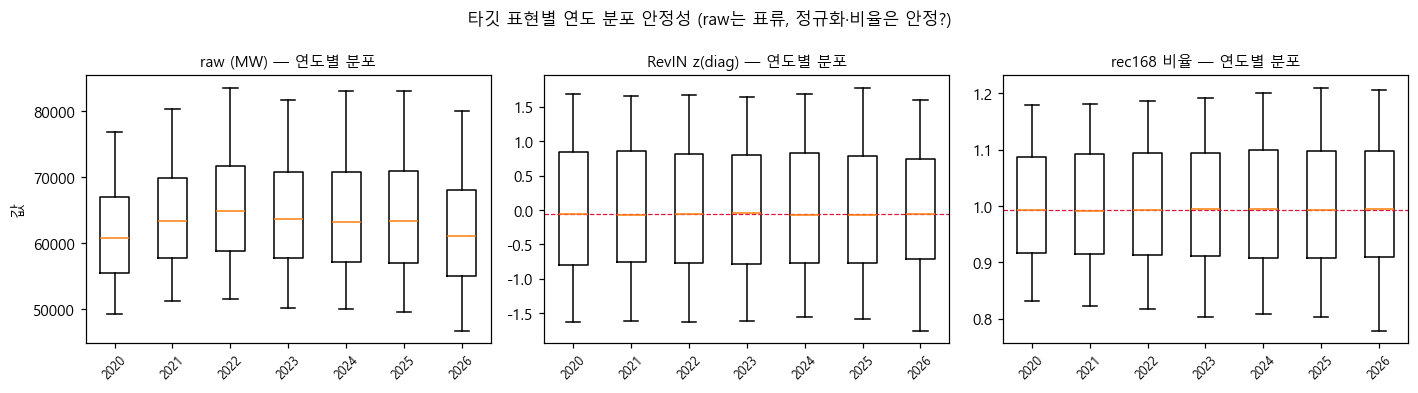

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (name, col) in zip(axes, REPS.items()):
    data = [d.loc[d.year==y, col].dropna().values for y in range(2020, 2027)]
    ax.boxplot(data, labels=[str(y) for y in range(2020,2027)], showfliers=False, whis=(5,95))
    ax.set_title(f'{name} — 연도별 분포', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if col != 'rep_raw': ax.axhline(d[col].median(), color='crimson', lw=0.8, ls='--')
axes[0].set_ylabel('값')
fig.suptitle('타깃 표현별 연도 분포 안정성 (raw는 표류, 정규화·비율은 안정?)', fontsize=11)
fig.tight_layout(); fig.savefig(os.path.join(FIG, '5-0b_rep_yearbox.png'), bbox_inches='tight'); plt.show()

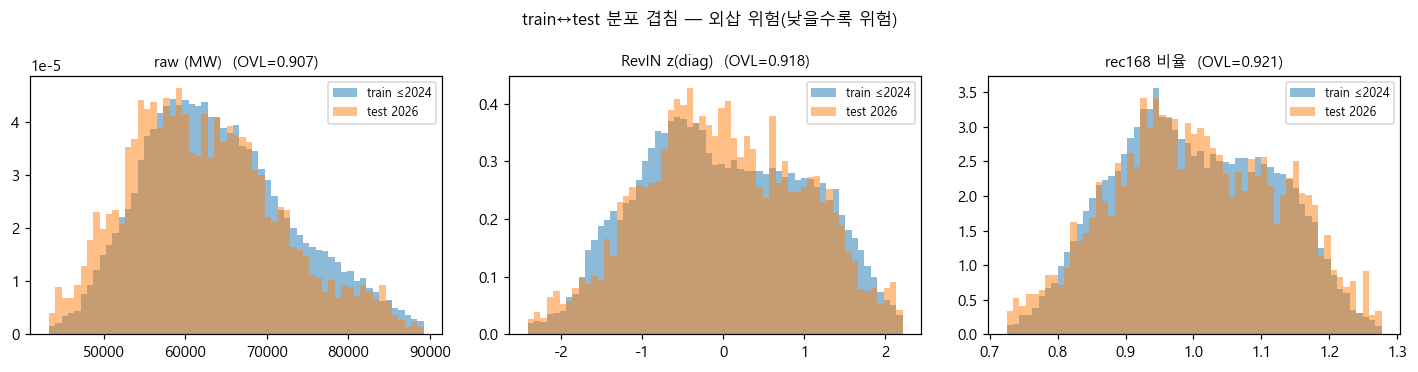

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (name, col) in zip(axes, REPS.items()):
    a = d.loc[tr_mask, col].dropna(); b = d.loc[te_mask, col].dropna()
    lo, hi = np.nanpercentile(pd.concat([a, b]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    ax.hist(a, bins, density=True, alpha=0.5, label='train ≤2024')
    ax.hist(b, bins, density=True, alpha=0.5, label='test 2026')
    ovl = overlap_coef(a.values, b.values)
    ax.set_title(f'{name}  (OVL={ovl:.3f})', fontsize=10); ax.legend(fontsize=8)
fig.suptitle('train↔test 분포 겹침 — 외삽 위험(낮을수록 위험)', fontsize=11)
fig.tight_layout(); fig.savefig(os.path.join(FIG, '5-0b_rep_traintest.png'), bbox_inches='tight'); plt.show()

## 2. context length(seq_len) 근거 — 자기상관 구조

PatchTST는 명시 lag 없이 **past_y 윈도우**로 자기상관을 본다 → seq_len = 모델이 보는 과거 길이.
- **ACF**: 어느 lag까지 상관이 살아있나(일·주 주기 피크).
- **PACF**: 직전 정보 통제 후 **독립적으로** 정보를 더하는 lag(과한 길이가 군더더기인지).
- **주간앵커 지속성**: y_t ↔ y_{t-168k} (k=1..6주) — 몇 주 전까지 신호가 남나 = 336/504/720 판단.

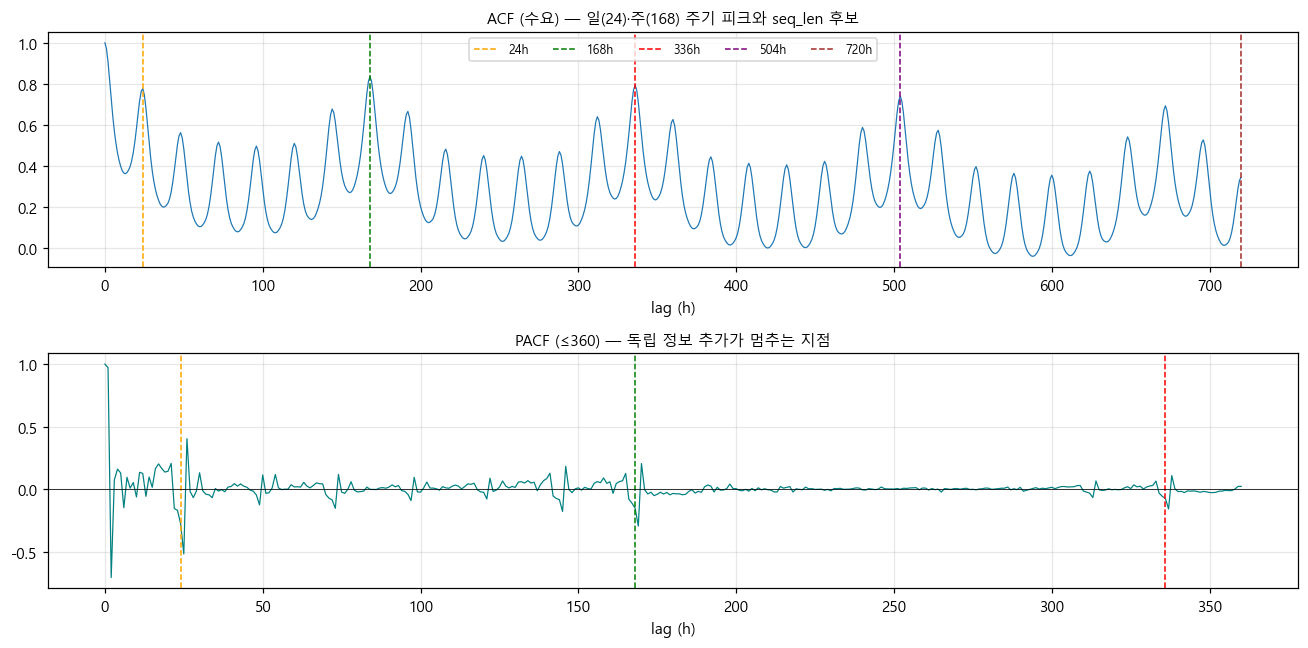

ACF @ lags: {24: 0.778, 168: 0.837, 336: 0.795, 504: 0.741, 720: 0.346}


In [5]:
from statsmodels.tsa.stattools import acf, pacf
ys = d.y.dropna().values
NAC = 720
ac = acf(ys, nlags=NAC, fft=True)
pac = pacf(ys, nlags=360, method='ywm')

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(range(NAC+1), ac, lw=0.8)
for L, c in [(24,'orange'),(168,'green'),(336,'red'),(504,'purple'),(720,'brown')]:
    axes[0].axvline(L, color=c, ls='--', lw=1, label=f'{L}h')
axes[0].set_title('ACF (수요) — 일(24)·주(168) 주기 피크와 seq_len 후보', fontsize=10)
axes[0].set_xlabel('lag (h)'); axes[0].legend(fontsize=8, ncol=5); axes[0].grid(alpha=0.3)
axes[1].plot(range(361), pac, lw=0.8, color='teal')
for L, c in [(24,'orange'),(168,'green'),(336,'red')]:
    axes[1].axvline(L, color=c, ls='--', lw=1)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('PACF (≤360) — 독립 정보 추가가 멈추는 지점', fontsize=10)
axes[1].set_xlabel('lag (h)'); axes[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, '5-0b_acf_pacf.png'), bbox_inches='tight'); plt.show()
print('ACF @ lags:', {L: round(float(ac[L]),3) for L in [24,168,336,504,720]})

In [6]:
# 주간앵커 지속성: y_t ↔ y_{t-168k}
rows = []
for k in range(1, 7):
    lagk = 168*k
    s1 = d.y.iloc[lagk:].values; s0 = d.y.iloc[:-lagk].values
    m = np.isfinite(s1) & np.isfinite(s0)
    rows.append(dict(주=k, lag_h=lagk, corr=round(float(np.corrcoef(s1[m], s0[m])[0,1]),3)))
wk = pd.DataFrame(rows)
wk.to_csv(os.path.join(TAB, '5-0b_weekly_persist.csv'), index=False, encoding='utf-8-sig')
print(wk.to_string(index=False))
print('\n해석: corr가 2~3주까지 높게 유지되면 seq_len 336~504 가 유리. 급감하면 168~336 충분.')

 주  lag_h  corr
 1    168 0.839
 2    336 0.799
 3    504 0.746
 4    672 0.701
 5    840 0.631
 6   1008 0.561

해석: corr가 2~3주까지 높게 유지되면 seq_len 336~504 가 유리. 급감하면 168~336 충분.


## 3. (보조) 낮(09-15h) 과대 비대칭 손실 α — 낮↔밤·계절 구조

v2 LGBM의 핵심 개선이 "낮 과대예측 페널티"였다(봄 낮 bias 절반). PatchTST에도 **약하게** 이식하기로
했으므로, 낮이 정말 특수한지(BTM 듀크커브로 한낮 수요가 눌리는지) 구조만 확인한다.

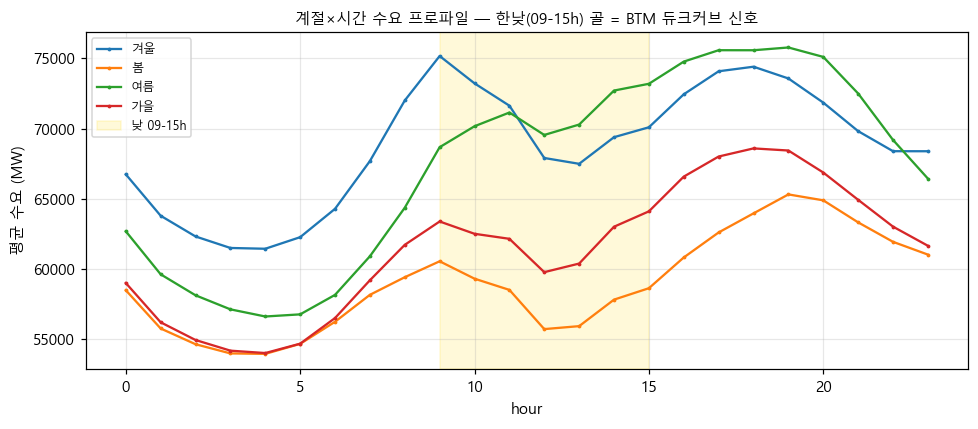

In [7]:
SEASON = {12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'}
d['season'] = d.month.map(SEASON)
prof = d.groupby(['season','hour']).y.mean().unstack(0)
fig, ax = plt.subplots(figsize=(9, 4))
for s in ['겨울','봄','여름','가을']:
    if s in prof: ax.plot(prof.index, prof[s], marker='.', ms=3, label=s)
ax.axvspan(9, 15, color='gold', alpha=0.15, label='낮 09-15h')
ax.set_xlabel('hour'); ax.set_ylabel('평균 수요 (MW)')
ax.set_title('계절×시간 수요 프로파일 — 한낮(09-15h) 골 = BTM 듀크커브 신호', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, '5-0b_dayprofile.png'), bbox_inches='tight'); plt.show()

## 4. 진단 요약 (REPORT_5-0b 로 이관)

아래 셀이 표현 결정 표를 다시 찍는다. 판단 기준:
- **타깃 표현**: OVL 높고 연도 표류 작은 표현 = RevIN / rec168 비율. raw는 표류·외삽 위험.
- **seq_len**: 주간앵커 지속성·PACF가 멈추는 지점으로 336 vs 504 결정.
- **α**: 낮 골이 뚜렷하면 약한 비대칭 유지.

다음: 좁힌 표현(보통 RevIN + 비율) × seq_len 후보로 `_gen_landdemand_patchtst.py` 학습 노트북 작성.

In [8]:
print('=== 타깃 표현 진단 ===')
print(rep_tab.to_string(index=False))
print('\n=== 주간앵커 지속성 ===')
print(wk.to_string(index=False))
print('\n산출: fig/5-0b_{rep_yearbox,rep_traintest,acf_pacf,dayprofile}.png, tab/5-0b_*.csv')

=== 타깃 표현 진단 ===
           표현  train_test_OVL  연도평균_표류  표류_상대  스케일_std
     raw (MW)           0.907 4250.372    6.6 9361.709
RevIN z(diag)           0.918    0.018 1245.2    1.032
    rec168 비율           0.921    0.002    0.2    0.118

=== 주간앵커 지속성 ===
 주  lag_h  corr
 1    168 0.839
 2    336 0.799
 3    504 0.746
 4    672 0.701
 5    840 0.631
 6   1008 0.561

산출: fig/5-0b_{rep_yearbox,rep_traintest,acf_pacf,dayprofile}.png, tab/5-0b_*.csv
